# Summarizing the old N messages and passing it along the latest M messgaes, and deleting the old N messgaes, coz we have its summary

In [1]:
from langgraph.graph import MessagesState
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI()

In [ ]:
class ChatState(MessagesState):
    summary: str


### u see we used MessagesState which have a predefined state['messages'] in it so we dint define it in above code, 
#class ChatState(TypedDict):
#    messages: Annotated[list[AnyMessage], add_messages] # Inherited
#    summary: str                                        # Added by you


In [7]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages and delete the rest from above, coz they got summarized
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [8]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [ ]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [10]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")


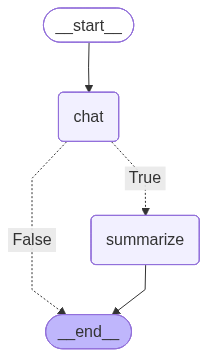

In [11]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)
graph

In [12]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [13]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [14]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='f1179547-60e2-47d5-a095-104a2e55810b')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum physics is the branch of physics that deals with the behavior of particl


In [15]:
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='f1179547-60e2-47d5-a095-104a2e55810b'), AIMessage(content='Quantum physics is the branch of physics that deals with the behavior of particles at the smallest scales, such as atoms and subatomic particles. It describes the behavior of these particles in terms of wave-particle duality, superposition, and entanglement, among other phenomena.\n\nQuantum physics has led to many important discoveries and technologies, such as quantum computing, quantum cryptography, and quantum entanglement. It also provides the theoretical framework for understanding a wide range of physical phenomena, from the behavior of electrons in materials to the structure of the universe at the largest scales.\n\nDespite its success in explaining the behavior of particles at the quantum level, quantum physics is also known for being counterintuitive and challenging to understand. Some of its key principles, such as superposition 

In [16]:
run_turn('What are some of Einstien"s fampus work')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='f1179547-60e2-47d5-a095-104a2e55810b'), AIMessage(content='Quantum physics is the branch of physics that deals with the behavior of particles at the smallest scales, such as atoms and subatomic particles. It describes the behavior of these particles in terms of wave-particle duality, superposition, and entanglement, among other phenomena.\n\nQuantum physics has led to many important discoveries and technologies, such as quantum computing, quantum cryptography, and quantum entanglement. It also provides the theoretical framework for understanding a wide range of physical phenomena, from the behavior of electrons in materials to the structure of the universe at the largest scales.\n\nDespite its success in explaining the behavior of particles at the quantum level, quantum physics is also known for being counterintuitive and challenging to understand. Some of its key principles, such as superposition 

In [17]:
run_turn('Explain special theory of relativity')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='f1179547-60e2-47d5-a095-104a2e55810b'), AIMessage(content='Quantum physics is the branch of physics that deals with the behavior of particles at the smallest scales, such as atoms and subatomic particles. It describes the behavior of these particles in terms of wave-particle duality, superposition, and entanglement, among other phenomena.\n\nQuantum physics has led to many important discoveries and technologies, such as quantum computing, quantum cryptography, and quantum entanglement. It also provides the theoretical framework for understanding a wide range of physical phenomena, from the behavior of electrons in materials to the structure of the universe at the largest scales.\n\nDespite its success in explaining the behavior of particles at the quantum level, quantum physics is also known for being counterintuitive and challenging to understand. Some of its key principles, such as superposition 